## Import Libraries

In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
import os
import matplotlib.pyplot as plt
import numpy as np

### Change directory for your current working directory


In [ ]:
os.getcwd()

'/home/vijay/Desktop/Student-Mark-Predictor/notebook'

In [5]:
os.chdir('..')

In [6]:
os.getcwd()

'/home/vijay/Desktop/Student-Mark-Predictor'

### Load Data

In [7]:
df = pd.read_csv('data/Student_Marks.csv')
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [8]:
x = df['time_study']
y = df['Marks']

In [10]:
x[:5],y[:5]

(0    4.508
 1    0.096
 2    3.133
 3    7.909
 4    7.811
 Name: time_study, dtype: float64,
 0    19.202
 1     7.734
 2    13.811
 3    53.018
 4    55.299
 Name: Marks, dtype: float64)

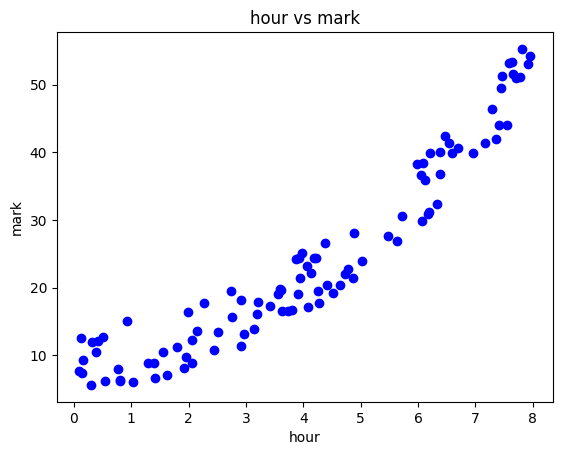

In [14]:
plt.scatter(x,y ,c='b')
plt.title('hour vs mark')
plt.xlabel('hour')
plt.ylabel('mark')
plt.show();

In [38]:
x.ndim, y.ndim

(1, 1)

In [44]:
x = np.array(x).reshape(-1,1)
y = np.array(y).reshape(-1,1)
x.ndim, y.ndim

(2, 2)

In [45]:
x.shape, y.shape

((100, 1), (100, 1))

In [46]:
len(x), len(y)

(100, 100)

### Split the data
1. training set
2. testing set
3. validation set

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [48]:
len(x_train), len(x_test), len(y_train), len(y_test)

(80, 20, 80, 20)

In [49]:
x_train.shape

(80, 1)

In [50]:
x_train = np.array(x_train)
x_train.shape

(80, 1)

### Lets build model
1. Linear regression
2. Polynomial regression


In [51]:
model1 = LinearRegression()
model1.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


accuracy_score : 0.9040228286990537
mean_absolute_error : 3.9689515350594236


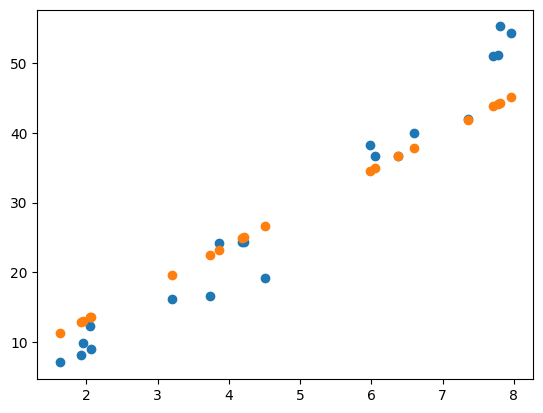

In [83]:
pred1 = model1.predict(x_test)
print(f'accuracy_score : {r2_score(y_test, pred1)}')
print(f'mean_absolute_error : {mean_absolute_error(y_test, pred1)}')
plt.scatter(x_test,y_test)
plt.scatter(x_test, pred1)

In [76]:
from sklearn.preprocessing import PolynomialFeatures

In [78]:
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.fit_transform(x_test)

model2 = LinearRegression()
model2.fit(x_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


accuracy_score : 0.968307254026016
mean_absolute_error : 2.397992141946072


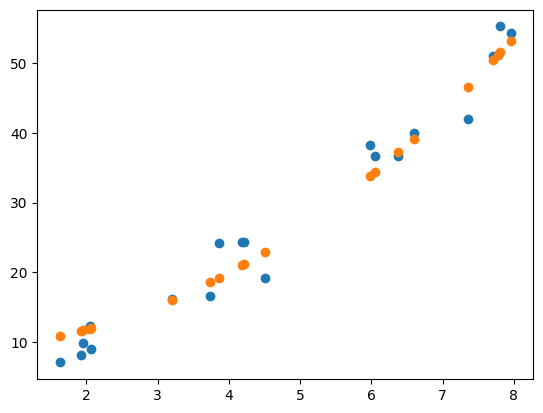

In [85]:
pred2 = model2.predict(x_test_poly)
print(f'accuracy_score : {r2_score(y_test, pred2)}')
print(f'mean_absolute_error : {mean_absolute_error(y_test, pred2)}')
plt.scatter(x_test,y_test)
plt.scatter(x_test, pred2)

### Save the model

In [86]:
import joblib

In [88]:
joblib.dump(model2, "models/student_mark_model.pkl")
print('Successfully saved!')

Successfully saved!
